<a href="https://colab.research.google.com/github/tapiaj-git/DS201Cap1/blob/main/DSCap1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
!wget "https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv"

--2026-09-14 01:35:15--  https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv
Resolving www.fhfa.gov (www.fhfa.gov)... 54.92.167.213
Connecting to www.fhfa.gov (www.fhfa.gov)|54.92.167.213|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17154972 (16M) [text/csv]
Saving to: ‘hpi_master.csv.1’

hpi_master.csv.1    100%[===================>]  16.36M  76.3MB/s    in 0.2s    

2026-09-14 01:35:16 (76.3 MB/s) - ‘hpi_master.csv.1’ saved [17154972/17154972]



# Part 1

In [38]:
import pandas as pd
url = "https://www.fhfa.gov/document/d/hpi/hpi_dictionary.xlsx"
df_def = pd.read_excel(url, sheet_name='Dictionary')
df_def

,Data Definitions,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Column,Field Name,Content,Type,Length,Example Values,Description
1,1,hpi_type,type of data,string,13,"traditional, developmental, distress-free, non...","The traditional, purchase-only, seasonally adj..."
2,2,hpi_flavor,flavor of HPI,string,16,"purchase-only, all-transactions, expanded-data",These are the three main types of FHFA HPIs an...
3,3,frequency,frequency of data,string,9,"monthly, quarterly",The only indexes produced on a monthly basis a...
4,4,level,level of geography,string,22,"USA or Census Division, State, MSA, Puerto Rico",The MSA is the lowest level of geography.
5,5,place_name,place name,string,57,"East North Central Division; Alabama; Abilene, TX",Traditional names.
6,6,place_id,place ID,string,6,"AK, 10180, DV_ENC, PR",Abbreviations or CBSA codes.
7,7,yr,year,numeric,4,"1975, 2000, 2013",Only the all-transactions data are published b...
8,8,period,period,numeric,2,"1, 10, 12",Period is either 1 through 4 for quarterly or ...
9,9,index_nsa,"index, non seasonally adjusted",numeric,6,"100.00, 79.05, 370.65",NaN


In [39]:
from pathlib import Path


relative_path = Path("hpi_master.csv")

df = pd.read_csv(relative_path)
df

/tmp/ipykernel_1788/3197980960.py:6: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(relative_path)


,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa,rstderr,note
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,1,100.00,100.00,NaN,NaN
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,2,100.87,100.87,NaN,NaN
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,3,101.32,100.90,NaN,NaN
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,4,101.73,100.96,NaN,NaN
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,5,102.32,101.31,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
186006,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2025,2,253.46,255.52,NaN,NaN
186007,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2025,3,243.73,239.74,NaN,NaN
186008,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2025,4,248.37,251.78,NaN,NaN
186009,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2026,1,272.77,272.95,NaN,NaN


In [40]:
df.describe()

,yr,period,index_nsa,index_sa,rstderr
count,186011.000000,186011.000000,186011.000000,96114.000000,58220.000000
mean,2006.159926,2.581014,199.962128,216.670407,2.673249
std,12.004355,1.358702,116.125443,113.512712,2.222155
min,1975.000000,1.000000,18.600000,72.780000,0.000000
25%,1997.000000,2.000000,119.610000,137.290000,1.060000
50%,2007.000000,3.000000,172.130000,187.210000,2.050000
75%,2016.000000,4.000000,241.380000,258.337500,3.600000
max,2026.000000,12.000000,1326.940000,1043.200000,15.750000


In [41]:
df.isna().sum()

,0
hpi_type,0
hpi_flavor,0
frequency,0
level,0
place_name,0
place_id,0
yr,0
period,0
index_nsa,0
index_sa,89897


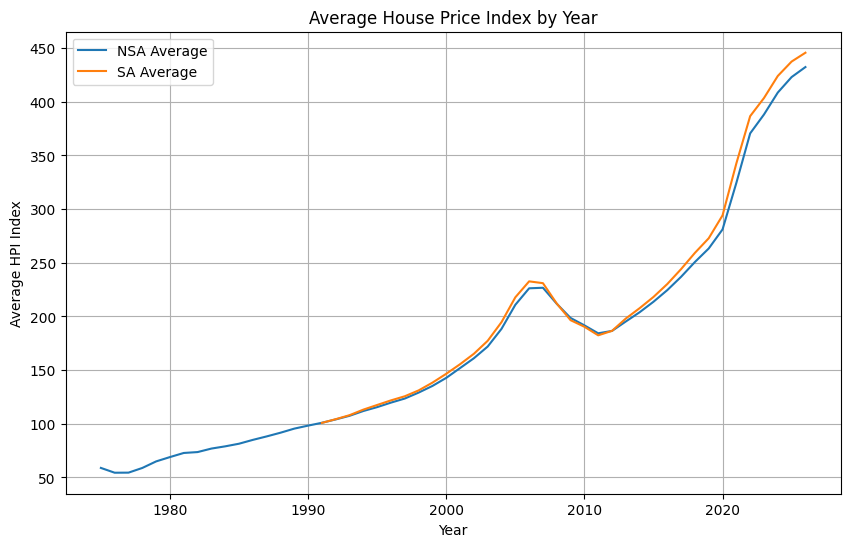

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

yearly_avg = df.groupby('yr')[['index_nsa', 'index_sa']].mean().reset_index()

plt.figure(figsize=(10, 6))

plt.plot(yearly_avg['yr'], yearly_avg['index_nsa'], label='NSA Average')
plt.plot(yearly_avg['yr'], yearly_avg['index_sa'], label='SA Average')

plt.xlabel('Year')
plt.ylabel('Average HPI Index')
plt.title('Average House Price Index by Year')
plt.legend()
plt.grid(True)

plt.show()

## When was data acquired?

After getting the relative path of the csv file, I named it df. I opened the df and can see that the data ranges from 1991 to 2026

 ## Where was the data acquired? (Which geographical locations are covered?)

## How was the data acquired? (What was the data collection method? Was it from  public records, real estate agencies, or another source?)


The FHFA House Price Index (HPI) is a broad measure of the movement of single-family house prices.  The HPI is a weighted, repeat-sales index, meaning that it measures average price changes in repeat sales or refinancings on the same properties. This information is obtained by reviewing repeat mortgage transactions on single-family properties whose mortgages have been purchased or securitized by Fannie Mae or Freddie Mac since January 1975.

## What are the attributes of this dataset? (Provide a brief description of each column in the dataset.)

## What type of data do these attributes contain? (Categorical, numerical, ordinal, etc)
